In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q timm torch torchvision scikit-learn matplotlib seaborn

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)


Using Device: cuda


In [5]:
TRAIN_PATH = "/content/drive/MyDrive/Bone Break Classification/Bone Break Classification"
VAL_PATH   = "/content/drive/MyDrive/Bone Break Classification/Bone Break Classification"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 0.0001

In [6]:
if not os.path.exists(TRAIN_PATH):
    raise Exception("❌ Train folder not found! Please create: Bone Break Classification/train/")
if not os.path.exists(VAL_PATH):
    raise Exception("❌ Val folder not found! Please create: Bone Break Classification/val/")


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [8]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=val_transform)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes Found:", class_names)
print("Total Classes:", NUM_CLASSES)


Classes Found: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
Total Classes: 10


In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [10]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)
print("✅ Swin Model Loaded Successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Swin Model Loaded Successfully!


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [12]:
def train_model(model, train_loader, val_loader, epochs):
    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):
        model.train()
        correct_train = 0
        total_train = 0
        train_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = correct_train / total_train
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)

                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = correct_val / total_val
        val_acc_list.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

    return train_acc_list, val_acc_list

In [13]:
train_acc_list, val_acc_list = train_model(model, train_loader, val_loader, EPOCHS)

Epoch [1/20] | Train Loss: 2.1806 | Train Acc: 0.2108 | Val Loss: 1.7306 | Val Acc: 0.4358
Epoch [2/20] | Train Loss: 1.7363 | Train Acc: 0.4181 | Val Loss: 1.3089 | Val Acc: 0.5766
Epoch [3/20] | Train Loss: 1.3817 | Train Acc: 0.5350 | Val Loss: 0.9506 | Val Acc: 0.6953
Epoch [4/20] | Train Loss: 0.9983 | Train Acc: 0.6687 | Val Loss: 0.5670 | Val Acc: 0.8335
Epoch [5/20] | Train Loss: 0.7703 | Train Acc: 0.7564 | Val Loss: 0.3425 | Val Acc: 0.9097
Epoch [6/20] | Train Loss: 0.5067 | Train Acc: 0.8406 | Val Loss: 0.1855 | Val Acc: 0.9637
Epoch [7/20] | Train Loss: 0.3589 | Train Acc: 0.8884 | Val Loss: 0.1386 | Val Acc: 0.9681
Epoch [8/20] | Train Loss: 0.2859 | Train Acc: 0.9097 | Val Loss: 0.1018 | Val Acc: 0.9734
Epoch [9/20] | Train Loss: 0.2314 | Train Acc: 0.9362 | Val Loss: 0.0816 | Val Acc: 0.9832
Epoch [10/20] | Train Loss: 0.2424 | Train Acc: 0.9221 | Val Loss: 0.0840 | Val Acc: 0.9743
Epoch [11/20] | Train Loss: 0.2203 | Train Acc: 0.9345 | Val Loss: 0.0445 | Val Acc: 0.98

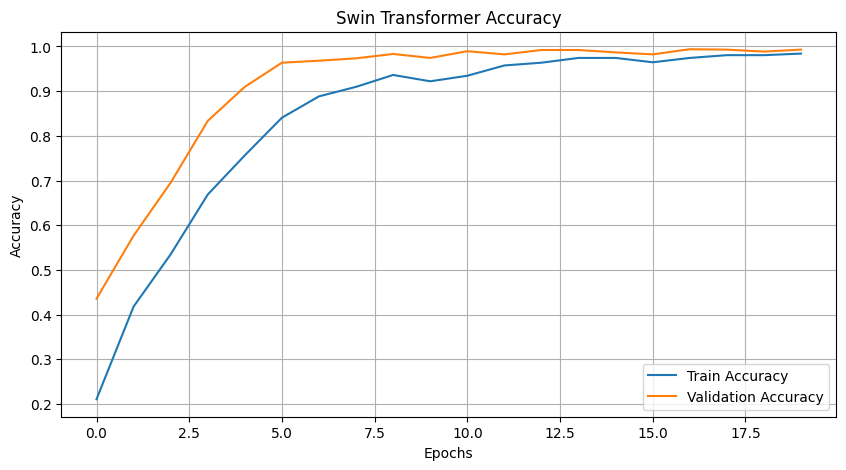

In [14]:
plt.figure(figsize=(10,5))
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.title("Swin Transformer Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


📌 Classification Report:

                       precision    recall  f1-score   support

    Avulsion fracture       1.00      0.99      1.00       123
  Comminuted fracture       0.99      1.00      0.99       148
 Fracture Dislocation       0.99      1.00      1.00       156
  Greenstick fracture       0.99      1.00      1.00       122
    Hairline Fracture       0.99      1.00      1.00       111
    Impacted fracture       0.98      0.99      0.98        84
Longitudinal fracture       1.00      0.96      0.98        80
     Oblique fracture       1.00      0.99      0.99        85
Pathological fracture       1.00      1.00      1.00       134
      Spiral Fracture       0.99      0.98      0.98        86

             accuracy                           0.99      1129
            macro avg       0.99      0.99      0.99      1129
         weighted avg       0.99      0.99      0.99      1129



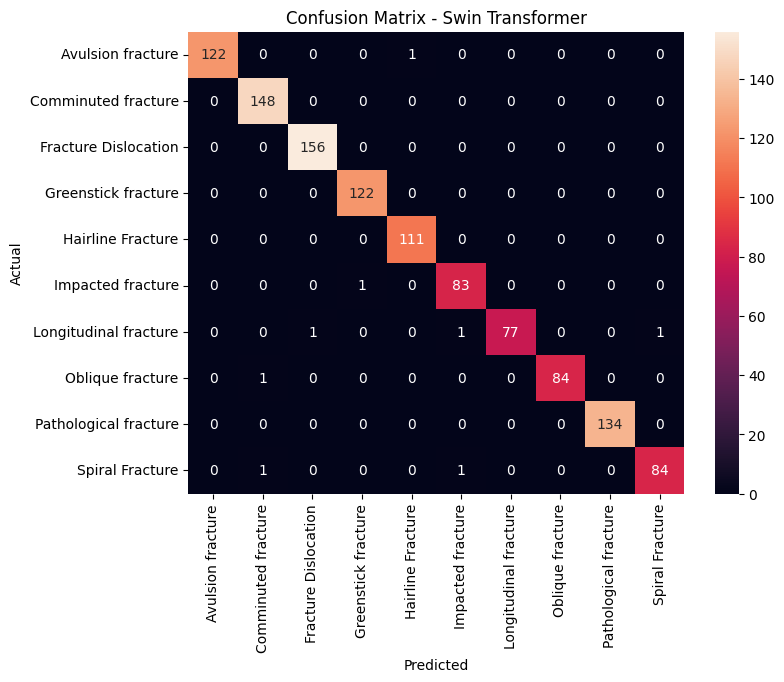

In [15]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("\n📌 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Swin Transformer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/Swin_BoneBreak_Model.pth"
torch.save(model.state_dict(), MODEL_SAVE_PATH)

print("\n✅ Model saved successfully at:", MODEL_SAVE_PATH)


✅ Model saved successfully at: /content/drive/MyDrive/Swin_BoneBreak_Model.pth
